# 300866 安克创新 — 模式发现 / Pattern Discovery

**目标**：在不预设策略的前提下，从多个维度扫描 300866 的 5min + day 数据，找出可能可交易的结构性模式，为后续策略提供思路。

**数据**：`ginkgo_bole.public.cnstock_kline_5m` + `cnstock_kline_day`（前者未复权 → 通过日线反推 `adj_factor` 修复）。

**约束（A 股微观结构）**：
- T+1：当日买入次日才能卖（已有持仓可做 T+0：先卖后买回）
- 涨跌停 ±20%（创业板）
- 5m bar 数：每天 48 根（09:35–11:30 + 13:00–15:00）

**已知线索（来自前序工作 `scripts/cnstock_intraday_reversal_smoke.py`）**：
- 全样本 z-score 反转策略在 OOS 段判定为 ❌ FAIL
- → 暗示「无条件均值回归」未必成立，需要分条件（regime / session 段 / 波动率档）找模式

**本 notebook 章节**：
1. 配置 & 加载数据
2. 数据完整性快照
3. 日级别收益与波动结构
4. 日内 (intraday) 时间序列效应
5. 隔夜 / 周内效应
6. 均值回归 vs 动量诊断（多 timeframe 自相关）
7. 量价结构与跟随性
8. 极端事件（涨跌停、tail z-score）
9. **观察总结 → 候选策略假设**

## 1. 配置 & 加载数据

复用 `scripts/cnstock_intraday_reversal_smoke.py::load_aligned_5m` 加载并修复复权对齐。

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100
# matplotlib 把 NotoSansCJK*.ttc 内的所有 SC/TC/JP/KR/HK face 都注册成同一个 family
# "Noto Sans CJK JP"（TTC 第一个 face），所以这里必须用 JP 这个名字才能命中——
# 字形覆盖中日韩，简体中文显示正常。
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "AR PL UMing CN", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ── 在这里改参数 ────────────────────────────────────────────────
CODE         = "300866"
START_DATE   = "2023-04-04"   # 上市后稳定期
END_DATE     = "2026-04-22"
BARS_PER_DAY = 48
TZ           = "Asia/Shanghai"
# ──────────────────────────────────────────────────────────────

from scripts.cnstock_intraday_reversal_smoke import load_aligned_5m

df_5m, df_day, adj_factor = load_aligned_5m(CODE, START_DATE, END_DATE)
df_5m = df_5m.copy()
df_day = df_day.copy()
df_5m["ts_cst"]  = pd.to_datetime(df_5m["ts_cst"])
df_day["ts_cst"] = pd.to_datetime(df_day["ts_cst"])
df_5m["date"]    = pd.to_datetime(df_5m["date_cst"])
df_day["date"]   = pd.to_datetime(df_day["date_cst"])
print(f"5m rows: {len(df_5m):,}  |  day rows: {len(df_day):,}")
print(f"5m range: {df_5m['ts_cst'].min()} → {df_5m['ts_cst'].max()}")
df_5m.head()

Loading 5m K-line for 300866 from 2023-04-04 to 2026-04-22...
  35,376 rows raw
Loading day K-line for 300866...
  742 rows day
  adj_factor: median=0.9719, min=0.6826, max=1.0000
  ✓ 复权对齐校验通过：max diff = 0.000000%
5m rows: 35,328  |  day rows: 742
5m range: 2023-04-04 09:35:00+08:00 → 2026-04-21 15:00:00+08:00


,trade_time,open_price,high_price,low_price,close_price,volume,amount,pre_close,suspension,ts_cst,hour_cst,minute_cst,date_cst,session_bar,adj_factor,daily_pre_close,date
0,2023-04-04 01:35:00+00:00,46.262116,46.483466,45.660321,46.130690,2305,15385292.0,66.75,0,2023-04-04 09:35:00+08:00,9,35,2023-04-04,1,0.691718,46.08,2023-04-04
1,2023-04-04 01:40:00+00:00,46.130690,46.621810,46.130690,46.573389,1921,12877943.0,66.69,0,2023-04-04 09:40:00+08:00,9,40,2023-04-04,2,0.691718,46.08,2023-04-04
2,2023-04-04 01:45:00+00:00,46.573389,46.573389,46.123772,46.255199,2297,15389325.0,67.33,0,2023-04-04 09:45:00+08:00,9,45,2023-04-04,3,0.691718,46.08,2023-04-04
3,2023-04-04 01:50:00+00:00,46.220613,46.400460,46.213696,46.358957,901,6035938.0,66.87,0,2023-04-04 09:50:00+08:00,9,50,2023-04-04,4,0.691718,46.08,2023-04-04
4,2023-04-04 01:55:00+00:00,46.358957,46.448880,46.275950,46.448880,1002,6711568.0,67.02,0,2023-04-04 09:55:00+08:00,9,55,2023-04-04,5,0.691718,46.08,2023-04-04


## 2. 数据完整性快照

确认覆盖度、停牌占比、日 bar 数分布；任何字段异常都先在这里看到。

5m bars            : 35,328
day rows           : 742
suspension share   : 0.00%
daily bars (med/min/max): 48 / 48 / 48
adj_factor range   : [0.6826, 1.0000]  median=0.9719
累计稀释 (1/min - 1): 46.5%


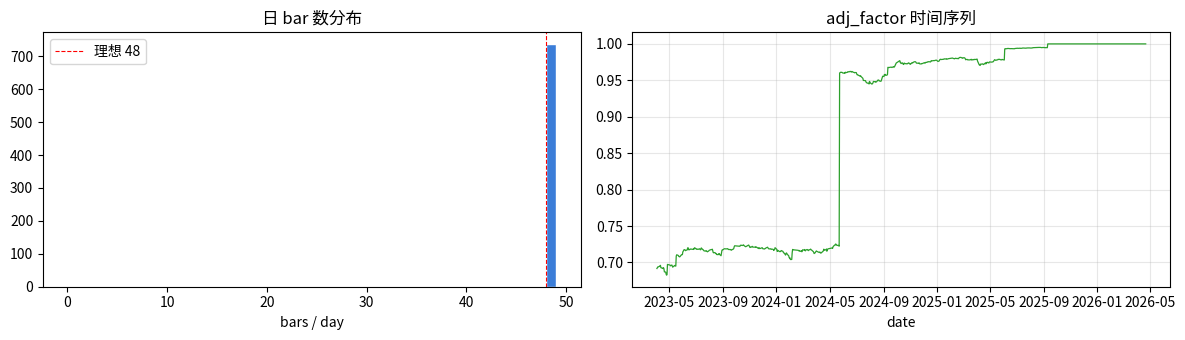

In [2]:
n_5m  = len(df_5m)
n_day = len(df_day)
susp  = (df_5m["suspension"] == 1).mean()
bars_per_date = df_5m.groupby("date").size()
missing_days  = (BARS_PER_DAY - bars_per_date).clip(lower=0)
print(f"5m bars            : {n_5m:,}")
print(f"day rows           : {n_day:,}")
print(f"suspension share   : {susp*100:.2f}%")
print(f"daily bars (med/min/max): {bars_per_date.median():.0f} / {bars_per_date.min()} / {bars_per_date.max()}")
print(f"adj_factor range   : [{adj_factor.min():.4f}, {adj_factor.max():.4f}]  median={adj_factor.median():.4f}")
print(f"累计稀释 (1/min - 1): {(1/adj_factor.min() - 1)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(bars_per_date.values, bins=range(0, BARS_PER_DAY + 2), color="#3b7dd8", edgecolor="white")
axes[0].axvline(BARS_PER_DAY, color="red", ls="--", lw=0.8, label=f"理想 {BARS_PER_DAY}")
axes[0].set_title("日 bar 数分布"); axes[0].set_xlabel("bars / day"); axes[0].legend()
axes[1].plot(adj_factor.index, adj_factor.values, color="C2", lw=0.9)
axes[1].set_title("adj_factor 时间序列"); axes[1].set_xlabel("date"); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 3. 日级别收益与波动结构

把日级 close-to-close 收益和 intraday 振幅分开看：
- 收益分布的 skew/kurt 决定均值回归 vs 动量倾向
- 滚动 21 日波动率给出 regime 切换信号
- TR% (高低价振幅 / 前收) 决定日内可获取的 alpha 上限

=== 日收益统计 ===
             value
mean        0.0017
std         0.0301
skew        1.0467
kurt        9.6700
min        -0.1935
max         0.2209
ann_vol     0.4780
ann_sharpe  0.8822


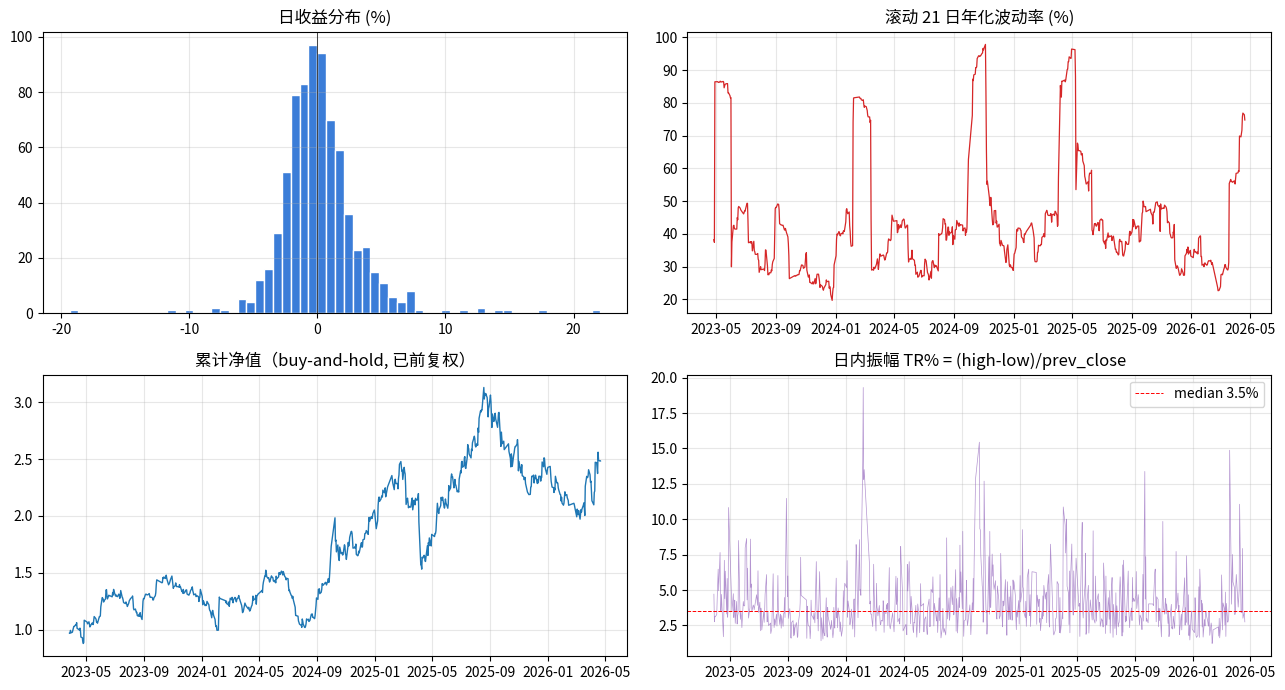

In [3]:
df_day["ret"]     = df_day["close_price"].pct_change()
df_day["tr_pct"]  = (df_day["high_price"] - df_day["low_price"]) / df_day["close_price"].shift(1)
df_day["vol_21d"] = df_day["ret"].rolling(21).std() * np.sqrt(252)
df_day["dow"]     = df_day["ts_cst"].dt.day_name()

ret = df_day["ret"].dropna()
summary = pd.DataFrame({
    "mean":  [ret.mean()],
    "std":   [ret.std()],
    "skew":  [ret.skew()],
    "kurt":  [ret.kurt()],
    "min":   [ret.min()],
    "max":   [ret.max()],
    "ann_vol":    [ret.std() * np.sqrt(252)],
    "ann_sharpe": [ret.mean() / ret.std() * np.sqrt(252)],
})
print("=== 日收益统计 ===")
print(summary.T.rename(columns={0: "value"}).round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0, 0].hist(ret * 100, bins=60, color="#3b7dd8", edgecolor="white")
axes[0, 0].axvline(0, color="black", lw=0.5)
axes[0, 0].set_title("日收益分布 (%)"); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(df_day["date"], df_day["vol_21d"] * 100, color="C3", lw=0.9)
axes[0, 1].set_title("滚动 21 日年化波动率 (%)"); axes[0, 1].grid(alpha=0.3)

eq = (1 + ret).cumprod()
axes[1, 0].plot(df_day["date"].iloc[1:], eq.values, color="C0", lw=1.0)
axes[1, 0].set_title("累计净值（buy-and-hold, 已前复权）"); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(df_day["date"], df_day["tr_pct"] * 100, color="C4", lw=0.5, alpha=0.7)
axes[1, 1].axhline(df_day["tr_pct"].median() * 100, color="red", ls="--", lw=0.7,
                   label=f"median {df_day['tr_pct'].median()*100:.1f}%")
axes[1, 1].set_title("日内振幅 TR% = (high-low)/prev_close"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

### 3.1 日 K 线 ⊕ 滚动 21 日波动率（regime 叠加视图）

把日线和波动率画在一张图上，做两件事：

1. 上图：日 K 线（红涨绿跌） + MA21 / MA60，背景按当时的波动率档位上色（浅绿=低 vol、浅红=高 vol、中 vol 不上色）
2. 下图：滚动 21 日年化波动率曲线 + 33% / 67% 分位阈值线

直觉上要看的几件事：
- 高 vol 区域（浅红）通常对应**剧烈方向性 move 后**而非之前 → vol 是反应性的，不是预测性的
- 价格突破 / 趋势启动是否更多发生在低 vol → 高 vol 的**切换瞬间**
- 长时间低 vol（浅绿连片）之后是不是更容易出现一波大行情（vol-of-vol 反弹）

vol regime 阈值 (年化%) : 低 < 34.5 | 中 [34.5, 43.4] | 高 > 43.4


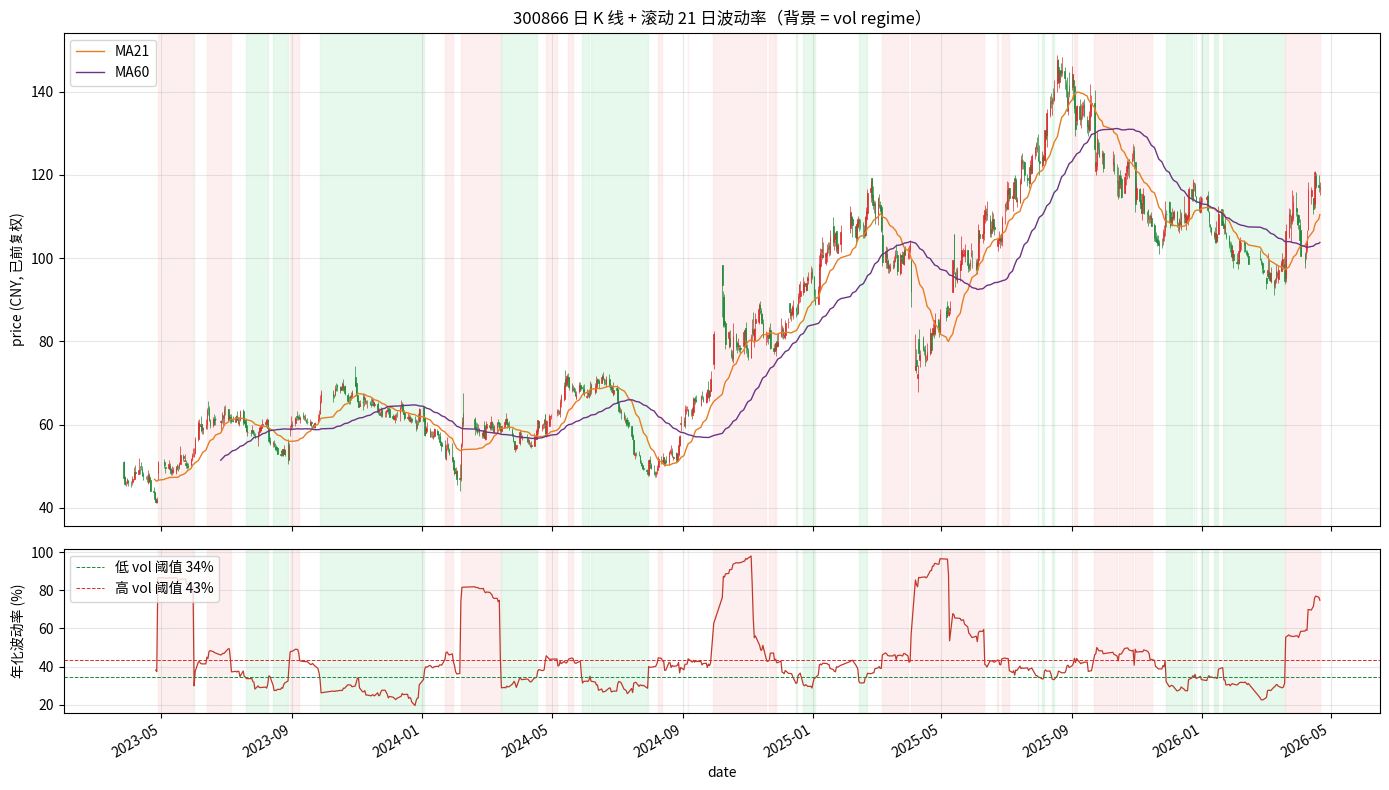


=== 不同 vol regime 下的日收益表现 ===
        n_days  mean_ret  cum_ret  win_rate  avg_abs
regime                                              
低 vol      238    -0.260  -48.382    42.437    1.481
中 vol      245     0.385  138.258    52.653    1.892
高 vol      238     0.429  125.552    48.739    2.754

regime 切换次数: 81  |  平均 regime 持续: 9.2 天


In [4]:
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

# ── regime 阈值：用 vol_21d 的 33% / 67% 分位 ──
vol_pct_series = df_day["vol_21d"] * 100
lo_thr = vol_pct_series.quantile(0.33)
hi_thr = vol_pct_series.quantile(0.67)
print(f"vol regime 阈值 (年化%) : 低 < {lo_thr:.1f} | 中 [{lo_thr:.1f}, {hi_thr:.1f}] | 高 > {hi_thr:.1f}")

# ── 移动均线 ──
df_day["ma_21"] = df_day["close_price"].rolling(21).mean()
df_day["ma_60"] = df_day["close_price"].rolling(60).mean()

dates_num = mdates.date2num(df_day["date"].to_numpy())

fig, (ax_p, ax_v) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# ── 上图：手绘日 K 线（红涨绿跌，A 股惯例）──
W = 0.6
for x, o, h, l, c in zip(
    dates_num,
    df_day["open_price"].to_numpy(),
    df_day["high_price"].to_numpy(),
    df_day["low_price"].to_numpy(),
    df_day["close_price"].to_numpy(),
):
    color = "#d92b2b" if c >= o else "#1f8a3a"
    ax_p.vlines(x, l, h, color=color, lw=0.5)
    body_h = max(abs(c - o), (h - l) * 0.005)
    ax_p.add_patch(Rectangle(
        (x - W / 2, min(o, c)), W, body_h,
        facecolor=color, edgecolor=color, lw=0.5,
    ))

ax_p.plot(dates_num, df_day["ma_21"].to_numpy(), color="#e67e22", lw=1.0, label="MA21")
ax_p.plot(dates_num, df_day["ma_60"].to_numpy(), color="#6c3483", lw=1.0, label="MA60")
ax_p.set_ylabel("price (CNY, 已前复权)")
ax_p.set_title(f"{CODE} 日 K 线 + 滚动 21 日波动率（背景 = vol regime）")
ax_p.legend(loc="upper left")
ax_p.grid(alpha=0.3)

# ── 给两图都铺 regime 背景：用游程合并连续同档区段，避免画 700+ 个 axvspan ──
def regime_of(v: float) -> str:
    if pd.isna(v):
        return "na"
    if v < lo_thr:
        return "lo"
    if v > hi_thr:
        return "hi"
    return "mid"

bg_color = {"lo": "#d4f4dd", "hi": "#fde2e2"}
labels = vol_pct_series.map(regime_of).to_numpy()
i = 0
while i < len(labels):
    lab = labels[i]
    j = i
    while j + 1 < len(labels) and labels[j + 1] == lab:
        j += 1
    if lab in bg_color:
        x0 = dates_num[i] - W / 2
        x1 = dates_num[j] + W / 2
        for ax in (ax_p, ax_v):
            ax.axvspan(x0, x1, color=bg_color[lab], alpha=0.55, zorder=0)
    i = j + 1

# ── 下图：滚动波动率 ──
ax_v.plot(dates_num, vol_pct_series.to_numpy(), color="#c0392b", lw=0.9)
ax_v.axhline(lo_thr, color="#1f8a3a", ls="--", lw=0.7, label=f"低 vol 阈值 {lo_thr:.0f}%")
ax_v.axhline(hi_thr, color="#d92b2b", ls="--", lw=0.7, label=f"高 vol 阈值 {hi_thr:.0f}%")
ax_v.set_ylabel("年化波动率 (%)")
ax_v.set_xlabel("date")
ax_v.legend(loc="upper left")
ax_v.grid(alpha=0.3)

ax_v.xaxis.set_major_locator(mdates.AutoDateLocator())
ax_v.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
fig.tight_layout(); plt.show()

# ── 数值面：不同 regime 下的价格表现 ──
df_day["regime"] = pd.cut(
    vol_pct_series,
    bins=[-np.inf, lo_thr, hi_thr, np.inf],
    labels=["低 vol", "中 vol", "高 vol"],
)
regime_stats = df_day.dropna(subset=["regime", "ret"]).groupby("regime", observed=True).agg(
    n_days   =("ret", "count"),
    mean_ret =("ret", lambda s: s.mean() * 100),
    cum_ret  =("ret", lambda s: ((1 + s).prod() - 1) * 100),
    win_rate =("ret", lambda s: (s > 0).mean() * 100),
    avg_abs  =("ret", lambda s: s.abs().mean() * 100),
).round(3)
print("\n=== 不同 vol regime 下的日收益表现 ===")
print(regime_stats)

# regime 切换次数：从低 vol 切到高 vol 的瞬间通常是大行情起点
shifts = (df_day["regime"].astype(str) != df_day["regime"].astype(str).shift()).sum() - 1
print(f"\nregime 切换次数: {shifts}  |  平均 regime 持续: {len(df_day) / max(shifts, 1):.1f} 天")


### 3.2 Meta-label 框架：通用 `regime_score()` 工具

**思路**：每个候选指标都把状态分桶（regime），然后回答同一个问题——"过去当指标处于状态 s 时，**在 t+1 收盘建仓、持有 N 日**的收益是什么样？"

输出是一张统一格式的 meta-label 表：

| 字段 | 含义 |
|---|---|
| `indicator` | 指标名（vol_21d / trend / drawdown / …） |
| `regime` | 该指标的桶（低/中/高，或自定义类别） |
| `h` | 持有期（1 / 5 / 21 个交易日） |
| `n` | 落入该桶的样本数 |
| `mean_pct` | 平均收益 (%) |
| `sharpe_ann` | 年化 Sharpe（用 √(252/h) scale） |
| `win_pct` | 胜率 (%) |
| `t` | 单样本 t 统计量（\|t\| > 2 视为显著） |

**关键约束（T+1 无前视）**：

```
信号 = 指标在 t 日收盘的状态
建仓 = t+1 日收盘价（A 股 T+1，最早能实际持有的时点）
平仓 = t+1+h 日收盘价
fwd_ret = close[t+1+h] / close[t+1] - 1
```

后续 §4 起每加一个指标，就调用一次 `regime_score()`，最后在 §9 横向合并所有 meta-label 表，按 `|t|` 和 `sharpe_ann` 排序就能看到**哪些指标在 300866 上有条件 alpha**。

In [5]:
def regime_score(
    df: pd.DataFrame,
    regime_col: str,
    *,
    price_col: str = "close_price",
    horizons: tuple[int, ...] = (1, 5, 21),
    indicator_name: str | None = None,
    entry_lag: int = 1,
) -> pd.DataFrame:
    """
    把任意分桶后的 regime 列映射到统一格式的 meta-label 表。

    参数
    ----
    regime_col      已分桶的列名（值是 category / str / int 都行，NaN 会被丢掉）
    price_col       计算 forward return 的价格列（默认 close_price，已前复权）
    horizons        持有期列表，单位为交易日
    indicator_name  显示名（None → 用 regime_col）
    entry_lag       建仓延迟。1 = T+1（A 股默认）；0 = T+0（仅用于研究对照）

    返回
    ----
    DataFrame: 列 = [indicator, regime, h, n, mean_pct, sharpe_ann, win_pct, t]
    """
    if regime_col not in df.columns:
        raise KeyError(f"column {regime_col!r} not in df")
    p = df[price_col]
    name = indicator_name or regime_col
    rows = []
    for h in horizons:
        # T+1 entry, T+1+h exit, no lookahead
        fwd = p.shift(-(entry_lag + h)) / p.shift(-entry_lag) - 1
        joined = pd.DataFrame({"regime": df[regime_col], "fwd": fwd}).dropna()
        for r, g in joined.groupby("regime", observed=True):
            n = len(g)
            if n < 5:
                continue
            mu, sd = g["fwd"].mean(), g["fwd"].std()
            sharpe = (mu / sd) * np.sqrt(252 / h) if sd > 0 else np.nan
            t      = (mu / (sd / np.sqrt(n)))      if sd > 0 else np.nan
            rows.append({
                "indicator":  name,
                "regime":     str(r),
                "h":          h,
                "n":          n,
                "mean_pct":   round(mu * 100, 3),
                "sharpe_ann": round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
                "win_pct":    round((g["fwd"] > 0).mean() * 100, 1),
                "t":          round(t, 2)      if not np.isnan(t)      else np.nan,
            })
    return pd.DataFrame(rows)


# 用一个全局 list 收集所有 meta-label 表，§9 时合并成 scoreboard
META_LABELS: list[pd.DataFrame] = []

# ── 示范：把 §3.1 已经造好的 vol_21d regime 直接喂进去 ──
ml_vol = regime_score(
    df_day,
    regime_col="regime",
    indicator_name="vol_21d",
    horizons=(1, 5, 21),
)
META_LABELS.append(ml_vol)

print("=== meta-label: vol_21d (33%/67% 分位分桶) ===")
print(ml_vol.to_string(index=False))

# 透视成 (regime × horizon) 的 Sharpe 矩阵，方便横向看
print("\n--- Sharpe (年化) ---")
print(ml_vol.pivot(index="regime", columns="h", values="sharpe_ann"))
print("\n--- t-stat ---")
print(ml_vol.pivot(index="regime", columns="h", values="t"))

# 显著条目（|t| > 2）单独打印
sig = ml_vol[ml_vol["t"].abs() > 2]
print(f"\n显著 meta-label 条目 (|t| > 2): {len(sig)} 条")
if len(sig):
    print(sig.to_string(index=False))


=== meta-label: vol_21d (33%/67% 分位分桶) ===
indicator regime  h   n  mean_pct  sharpe_ann  win_pct     t
  vol_21d  低 vol  1 238     0.038        0.24     45.4  0.23
  vol_21d  中 vol  1 245     0.394        1.74     51.0  1.71
  vol_21d  高 vol  1 236     0.127        0.71     47.5  0.68
  vol_21d  低 vol  5 238    -0.209       -0.27     43.3 -0.59
  vol_21d  中 vol  5 245     1.917        1.88     57.6  4.15
  vol_21d  高 vol  5 232     0.737        0.79     53.4  1.69
  vol_21d  低 vol 21 237    -1.290       -0.37     37.1 -1.63
  vol_21d  中 vol 21 245     6.852        1.71     67.3  7.71
  vol_21d  高 vol 21 217     4.360        1.11     58.1  4.72

--- Sharpe (年化) ---
h         1     5     21
regime                  
中 vol   1.74  1.88  1.71
低 vol   0.24 -0.27 -0.37
高 vol   0.71  0.79  1.11

--- t-stat ---
h         1     5     21
regime                  
中 vol   1.71  4.15  7.71
低 vol   0.23 -0.59 -1.63
高 vol   0.68  1.69  4.72

显著 meta-label 条目 (|t| > 2): 3 条
indicator regime  h   n  me

### 3.3 更多日级 meta-labels：trend / drawdown / volume / RSI

复用 `regime_score()`，把 4 个常见日级指标各自分桶并打分。每个指标一个 cell，方便单独迭代桶切方式或调整 horizon。

| 指标 | 桶切方式 | 经济直觉 |
|------|----------|---------|
| **trend** | `close vs MA60` × `MA60 slope` → 4 桶 | 趋势所处阶段（强势 / 减弱 / 反弹 / 弱势） |
| **drawdown_60d** | 距 60 日高点的回撤深度 → 4 桶 | 仓位所处的"位置感"（高位 vs 深回撤） |
| **volume_z_21d** | 21 日 log 成交量 z-score → 5 桶 | 资金参与度（放量 vs 缩量） |
| **RSI14** | RSI 经典分档 → 4 桶 | 短期超买 / 超卖 |

跑完后所有结果都会 append 到 `META_LABELS`，§9 时统一合并。

In [6]:
# ── Meta-label #2: trend regime = (close vs MA60) × (MA60 slope) ──
df_day["ma_60"]       = df_day["close_price"].rolling(60).mean()
df_day["ma_60_slope"] = df_day["ma_60"].diff(5)  # 5 日斜率方向
df_day["above_ma60"]  = df_day["close_price"] > df_day["ma_60"]
df_day["ma60_up"]     = df_day["ma_60_slope"] > 0

def _trend_label(row):
    if pd.isna(row["ma_60"]) or pd.isna(row["ma_60_slope"]):
        return np.nan
    if row["above_ma60"] and row["ma60_up"]:           return "1.强势(上+涨)"
    if row["above_ma60"] and not row["ma60_up"]:       return "2.顶背离(上+跌)"
    if not row["above_ma60"] and row["ma60_up"]:       return "3.反弹(下+涨)"
    return "4.弱势(下+跌)"

df_day["trend_regime"] = df_day.apply(_trend_label, axis=1)

print("=== 各 trend regime 的样本数 ===")
print(df_day["trend_regime"].value_counts().sort_index())

ml_trend = regime_score(df_day, "trend_regime", indicator_name="trend")
META_LABELS.append(ml_trend)

print("\n=== meta-label: trend ===")
print(ml_trend.to_string(index=False))
print("\n--- Sharpe ---")
print(ml_trend.pivot(index="regime", columns="h", values="sharpe_ann"))
print("\n--- t-stat ---")
print(ml_trend.pivot(index="regime", columns="h", values="t"))
sig = ml_trend[ml_trend["t"].abs() > 2]
print(f"\n显著条目: {len(sig)}")
if len(sig): print(sig.to_string(index=False))


=== 各 trend regime 的样本数 ===
trend_regime
1.强势(上+涨)     300
2.顶背离(上+跌)    103
3.反弹(下+涨)      84
4.弱势(下+跌)     191
Name: count, dtype: int64

=== meta-label: trend ===
indicator     regime  h   n  mean_pct  sharpe_ann  win_pct     t
    trend  1.强势(上+涨)  1 298     0.071        0.44     49.7  0.47
    trend 2.顶背离(上+跌)  1 103     0.535        2.84     49.5  1.81
    trend  3.反弹(下+涨)  1  84    -0.648       -3.00     44.0 -1.73
    trend  4.弱势(下+跌)  1 191     0.374        1.89     45.5  1.65
    trend  1.强势(上+涨)  5 295     0.336        0.48     50.2  1.17
    trend 2.顶背离(上+跌)  5 102     2.149        2.01     55.9  2.87
    trend  3.反弹(下+涨)  5  84    -2.489       -2.19     33.3 -2.82
    trend  4.弱势(下+跌)  5 191     1.866        1.92     56.5  3.74
    trend  1.强势(上+涨) 21 295     0.898        0.27     49.5  1.33
    trend 2.顶背离(上+跌) 21  89     7.220        2.22     70.8  6.04
    trend  3.反弹(下+涨) 21  84    -7.727       -2.31     17.9 -6.11
    trend  4.弱势(下+跌) 21 188     8.702        2.02     

In [7]:
# ── Meta-label #3: drawdown_60d = 距 60 日滚动高点的回撤 ──
roll_high = df_day["close_price"].rolling(60, min_periods=20).max()
df_day["dd_60d"] = df_day["close_price"] / roll_high - 1   # 总是 ≤ 0

def _dd_label(d):
    if pd.isna(d):  return np.nan
    if d >= -0.05:  return "A.高点±5%"
    if d >= -0.15:  return "B.回撤5-15%"
    if d >= -0.25:  return "C.回撤15-25%"
    return                 "D.深回撤>25%"

df_day["dd_regime"] = df_day["dd_60d"].apply(_dd_label)

print("=== 各 drawdown regime 的样本数 ===")
print(df_day["dd_regime"].value_counts().sort_index())

ml_dd = regime_score(df_day, "dd_regime", indicator_name="drawdown_60d")
META_LABELS.append(ml_dd)

print("\n=== meta-label: drawdown_60d ===")
print(ml_dd.to_string(index=False))
print("\n--- Sharpe ---")
print(ml_dd.pivot(index="regime", columns="h", values="sharpe_ann"))
print("\n--- t-stat ---")
print(ml_dd.pivot(index="regime", columns="h", values="t"))
sig = ml_dd[ml_dd["t"].abs() > 2]
print(f"\n显著条目: {len(sig)}")
if len(sig): print(sig.to_string(index=False))


=== 各 drawdown regime 的样本数 ===
dd_regime
A.高点±5%       238
B.回撤5-15%     274
C.回撤15-25%    144
D.深回撤>25%      67
Name: count, dtype: int64

=== meta-label: drawdown_60d ===
   indicator     regime  h   n  mean_pct  sharpe_ann  win_pct     t
drawdown_60d    A.高点±5%  1 236     0.176        0.99     47.0  0.95
drawdown_60d  B.回撤5-15%  1 274    -0.062       -0.36     50.7 -0.38
drawdown_60d C.回撤15-25%  1 144     0.288        1.35     43.8  1.02
drawdown_60d  D.深回撤>25%  1  67     1.020        4.20     49.3  2.16
drawdown_60d    A.高点±5%  5 232     1.230        1.43     54.3  3.06
drawdown_60d  B.回撤5-15%  5 274    -0.365       -0.41     44.2 -0.96
drawdown_60d C.回撤15-25%  5 144     0.854        0.93     51.4  1.57
drawdown_60d  D.深回撤>25%  5  67     4.795        4.28     73.1  4.94
drawdown_60d    A.高点±5% 21 229     2.842        0.80     56.8  3.49
drawdown_60d  B.回撤5-15% 21 262    -0.001       -0.00     41.2 -0.00
drawdown_60d C.回撤15-25% 21 143     3.085        0.76     54.5  2.61
drawdown_60

In [8]:
# ── Meta-label #4: volume_z_21d = 21 日 log(volume) z-score ──
log_vol = np.log(df_day["volume"].replace(0, np.nan))
df_day["vol_z_21d"] = (log_vol - log_vol.rolling(21).mean()) / log_vol.rolling(21).std()

df_day["vol_z_regime"] = pd.cut(
    df_day["vol_z_21d"],
    bins=[-np.inf, -1.0, -0.5, 0.5, 1.0, np.inf],
    labels=["A.缩量<-1σ", "B.偏缩-1~-0.5σ", "C.中性±0.5σ", "D.偏放0.5~1σ", "E.放量>1σ"],
)

print("=== 各 vol_z regime 的样本数 ===")
print(df_day["vol_z_regime"].value_counts().sort_index())

ml_vz = regime_score(df_day, "vol_z_regime", indicator_name="volume_z_21d")
META_LABELS.append(ml_vz)

print("\n=== meta-label: volume_z_21d ===")
print(ml_vz.to_string(index=False))
print("\n--- Sharpe ---")
print(ml_vz.pivot(index="regime", columns="h", values="sharpe_ann"))
print("\n--- t-stat ---")
print(ml_vz.pivot(index="regime", columns="h", values="t"))
sig = ml_vz[ml_vz["t"].abs() > 2]
print(f"\n显著条目: {len(sig)}")
if len(sig): print(sig.to_string(index=False))


=== 各 vol_z regime 的样本数 ===
vol_z_regime
A.缩量<-1σ        120
B.偏缩-1~-0.5σ    126
C.中性±0.5σ       262
D.偏放0.5~1σ       94
E.放量>1σ         120
Name: count, dtype: int64

=== meta-label: volume_z_21d ===
   indicator       regime  h   n  mean_pct  sharpe_ann  win_pct    t
volume_z_21d     A.缩量<-1σ  1 120     0.304        1.71     52.5 1.18
volume_z_21d B.偏缩-1~-0.5σ  1 125     0.114        0.57     47.2 0.40
volume_z_21d    C.中性±0.5σ  1 261     0.185        0.95     47.1 0.96
volume_z_21d   D.偏放0.5~1σ  1  94     0.323        1.71     47.9 1.04
volume_z_21d      E.放量>1σ  1 120     0.056        0.30     46.7 0.21
volume_z_21d     A.缩量<-1σ  5 120     0.210        0.22     45.0 0.34
volume_z_21d B.偏缩-1~-0.5σ  5 125     0.799        0.86     53.6 1.35
volume_z_21d    C.中性±0.5σ  5 258     1.401        1.42     52.7 3.20
volume_z_21d   D.偏放0.5~1σ  5  94     1.075        1.36     57.4 1.85
volume_z_21d      E.放量>1σ  5 119     0.207        0.24     48.7 0.37
volume_z_21d     A.缩量<-1σ 21 120     1.5

In [9]:
# ── Meta-label #5: RSI14 = 经典 Wilder 14 日 RSI ──
delta = df_day["close_price"].diff()
gain  = delta.clip(lower=0)
loss  = -delta.clip(upper=0)
# Wilder 平滑 ≈ EMA with alpha=1/14
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df_day["rsi_14"] = 100 - 100 / (1 + rs)

df_day["rsi_regime"] = pd.cut(
    df_day["rsi_14"],
    bins=[0, 30, 50, 70, 100],
    labels=["A.超卖<30", "B.弱30-50", "C.强50-70", "D.超买>70"],
    include_lowest=True,
)

print("=== 各 RSI regime 的样本数 ===")
print(df_day["rsi_regime"].value_counts().sort_index())

ml_rsi = regime_score(df_day, "rsi_regime", indicator_name="rsi_14")
META_LABELS.append(ml_rsi)

print("\n=== meta-label: rsi_14 ===")
print(ml_rsi.to_string(index=False))
print("\n--- Sharpe ---")
print(ml_rsi.pivot(index="regime", columns="h", values="sharpe_ann"))
print("\n--- t-stat ---")
print(ml_rsi.pivot(index="regime", columns="h", values="t"))
sig = ml_rsi[ml_rsi["t"].abs() > 2]
print(f"\n显著条目: {len(sig)}")
if len(sig): print(sig.to_string(index=False))


=== 各 RSI regime 的样本数 ===
rsi_regime
A.超卖<30      56
B.弱30-50    268
C.强50-70    367
D.超买>70      50
Name: count, dtype: int64

=== meta-label: rsi_14 ===
indicator   regime  h   n  mean_pct  sharpe_ann  win_pct    t
   rsi_14  A.超卖<30  1  56     0.702        2.34     39.3 1.10
   rsi_14 B.弱30-50  1 268     0.107        0.68     49.3 0.70
   rsi_14 C.强50-70  1 365     0.159        0.85     48.2 1.02
   rsi_14  D.超买>70  1  50     0.021        0.10     46.0 0.04
   rsi_14  A.超卖<30  5  56     1.968        1.34     50.0 1.41
   rsi_14 B.弱30-50  5 268     0.113        0.12     47.4 0.28
   rsi_14 C.强50-70  5 361     1.075        1.33     53.2 3.55
   rsi_14  D.超买>70  5  50     1.897        1.77     60.0 1.76
   rsi_14  A.超卖<30 21  56    10.971        2.75     82.1 5.94
   rsi_14 B.弱30-50 21 265     1.536        0.36     45.7 1.71
   rsi_14 C.强50-70 21 348     3.615        1.01     58.9 5.45
   rsi_14  D.超买>70 21  50     4.128        1.15     48.0 2.34

--- Sharpe ---
h           1     5    

### 3.4 事件去重：纠正 forward-return 样本重叠

**问题**：21 日 forward return 用滚动窗口算，相邻样本重叠 20/21 ≈ 95%。所以"深回撤 67 天"看起来 n=67，实际可能只是 3-5 段独立事件。t-stat 严重高估。

**修正办法**：把 regime 列折叠成"**首次进入该状态**的当天"。一段连续 15 天的"深回撤"只算 1 个 event。这相当于 López de Prado 在 *Advances in Financial ML* 里讲的 **uniqueness-weighted sample**——样本之间互相独立，t-stat 才能信。

**预期效果**：
- 总样本数会大幅缩水（~10-30 倍）
- 显著的 |t| 会下降，但**真信号应该仍然显著**（n=10 的 t=4 比 n=200 的 t=4 更可信）
- 假信号会塌陷到 |t| < 2

跑完后我们会得到一份**真正可下注的 meta-label scoreboard**。

In [ ]:
def first_day_of_regime(s: pd.Series) -> pd.Series:
    """把 regime 列折叠：连续同状态的 run 只保留首日，其余设为 NaN。"""
    s_obj = s.astype("object")
    is_event = s_obj != s_obj.shift()
    # 第一行 NaN.shift() 是 NaN，is_event=True，但 NaN 状态本身要保留 NaN
    return s_obj.where(is_event & s_obj.notna(), other=np.nan)


# ── 对每个指标都生成事件版 regime 列，跑 regime_score ──
indicator_specs = [
    ("regime",        "vol_21d"),
    ("trend_regime",  "trend"),
    ("dd_regime",     "drawdown_60d"),
    ("vol_z_regime",  "volume_z_21d"),
    ("rsi_regime",    "rsi_14"),
]

EVENT_LABELS: list[pd.DataFrame] = []
for col, name in indicator_specs:
    event_col = f"{col}_event"
    df_day[event_col] = first_day_of_regime(df_day[col])
    n_events = df_day[event_col].notna().sum()
    n_full   = df_day[col].notna().sum()
    print(f"\n--- {name}: {n_events} events vs {n_full} 全样本天 (压缩 {n_full/max(n_events,1):.1f}x) ---")
    print(df_day[event_col].value_counts().sort_index())

    ml_evt = regime_score(df_day, event_col, indicator_name=f"{name} (event)", horizons=(1, 5, 21))
    EVENT_LABELS.append(ml_evt)


# ── 合并 + 排序：事件去重后的 scoreboard ──
event_board = pd.concat(EVENT_LABELS, ignore_index=True)
event_board["abs_t"] = event_board["t"].abs()

print("\n\n========== 事件去重 scoreboard (按 |t| 排序，仅显示 |t|>1.5) ==========")
shown = event_board[event_board["abs_t"] > 1.5].sort_values("abs_t", ascending=False)
print(shown[["indicator", "regime", "h", "n", "mean_pct", "sharpe_ann", "win_pct", "t"]].to_string(index=False))


# ── 对照：与全样本版的 t-stat 对比 ──
print("\n\n========== 全样本 vs 事件去重对比（h=21）==========")
full_board = pd.concat(META_LABELS, ignore_index=True)
full_board = full_board[full_board["h"] == 21][["indicator", "regime", "n", "t"]].rename(
    columns={"n": "n_full", "t": "t_full"})

evt21 = event_board[event_board["h"] == 21].copy()
evt21["indicator"] = evt21["indicator"].str.replace(" (event)", "", regex=False)
evt21 = evt21[["indicator", "regime", "n", "t"]].rename(columns={"n": "n_evt", "t": "t_evt"})

cmp = full_board.merge(evt21, on=["indicator", "regime"], how="outer")
cmp["t_shrinkage"] = (cmp["t_full"].abs() - cmp["t_evt"].abs()).round(2)
cmp = cmp.sort_values("t_full", key=lambda s: s.abs(), ascending=False)
print(cmp.to_string(index=False))


## 4. 日内 (intraday) 时间序列效应

对 5m 数据按 `session_bar` (1=09:35–09:40, …, 48=14:55–15:00) 聚合，看：
- 平均 5m 收益（U / W / 单调？）
- 平均成交量（典型 U 形：开盘 + 尾盘高）
- 收益绝对值 (≈ 5m 波动率) 的日内分布

如果某些 session_bar 的均值收益显著 ≠ 0，就是日内 alpha 的入口。

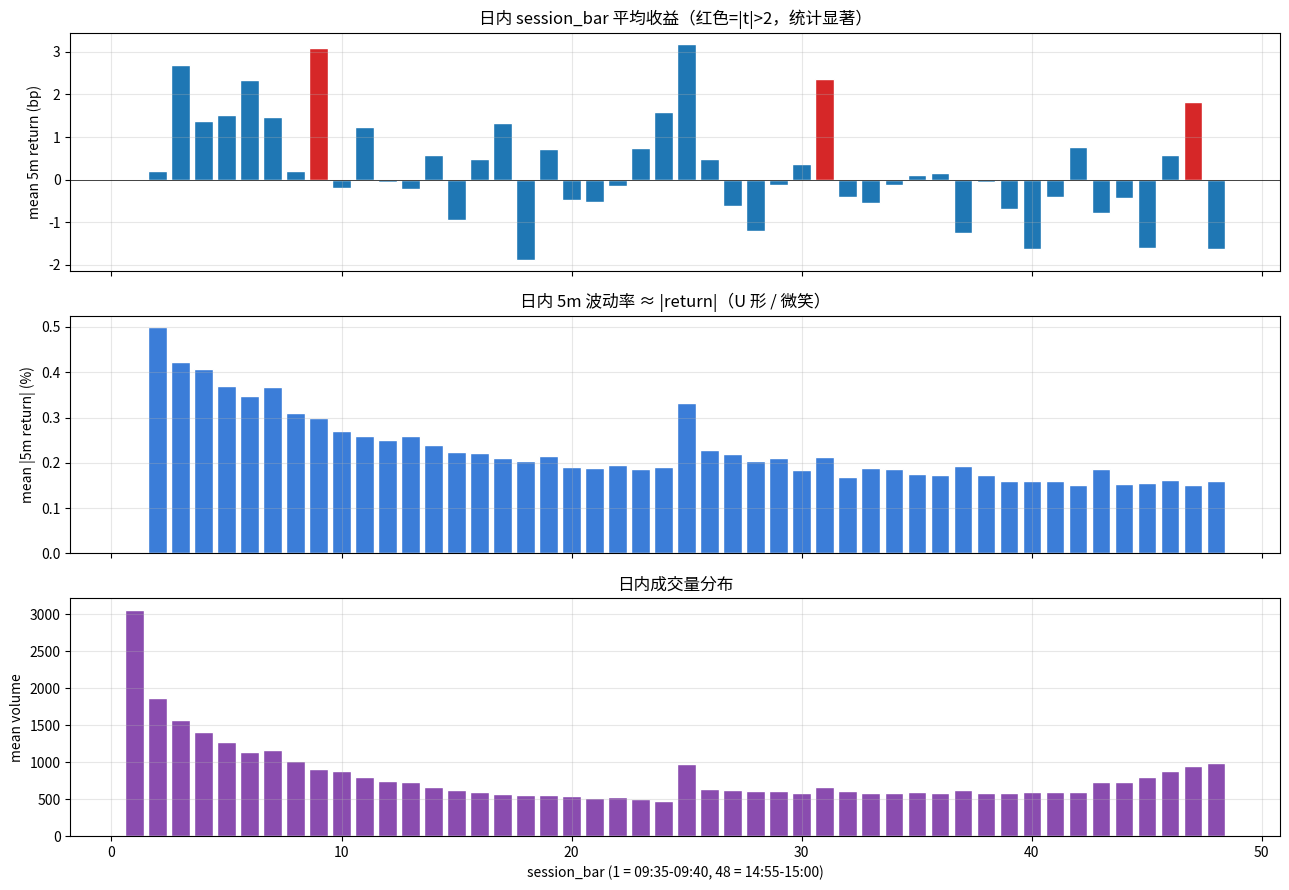


=== 显著 session_bar (|t| > 2) ===
             mean_ret   std_ret   abs_ret    mean_vol    n    t_stat
session_bar                                                         
47           0.000183  0.002186  0.001506  952.085598  736  2.276394
31           0.000237  0.002920  0.002120  665.354620  736  2.202248
9            0.000309  0.004012  0.002981  905.980978  736  2.091877


In [10]:
df_5m["ret_5m"] = df_5m.groupby("date")["close_price"].pct_change()

by_bar = df_5m.groupby("session_bar").agg(
    mean_ret=("ret_5m", "mean"),
    std_ret =("ret_5m", "std"),
    abs_ret =("ret_5m", lambda s: s.abs().mean()),
    mean_vol=("volume", "mean"),
    n=("ret_5m", "count"),
)
by_bar["t_stat"] = by_bar["mean_ret"] / (by_bar["std_ret"] / np.sqrt(by_bar["n"]))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = ["C3" if abs(t) > 2 else "C0" for t in by_bar["t_stat"].values]
axes[0].bar(by_bar.index, by_bar["mean_ret"] * 1e4, color=colors, edgecolor="white")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_ylabel("mean 5m return (bp)")
axes[0].set_title("日内 session_bar 平均收益（红色=|t|>2，统计显著）")
axes[0].grid(alpha=0.3)

axes[1].bar(by_bar.index, by_bar["abs_ret"] * 100, color="#3b7dd8", edgecolor="white")
axes[1].set_ylabel("mean |5m return| (%)")
axes[1].set_title("日内 5m 波动率 ≈ |return|（U 形 / 微笑）")
axes[1].grid(alpha=0.3)

axes[2].bar(by_bar.index, by_bar["mean_vol"], color="#8a4caf", edgecolor="white")
axes[2].set_ylabel("mean volume")
axes[2].set_xlabel("session_bar (1 = 09:35-09:40, 48 = 14:55-15:00)")
axes[2].set_title("日内成交量分布")
axes[2].grid(alpha=0.3)
fig.tight_layout(); plt.show()

sig_bars = by_bar[by_bar["t_stat"].abs() > 2].sort_values("t_stat", key=abs, ascending=False)
print("\n=== 显著 session_bar (|t| > 2) ===")
print(sig_bars.round(6))

## 5. 隔夜 / 周内效应

- **overnight gap** = open / prev_close - 1：A 股集合竞价产生的跳空，可能反转或延续
- **day-of-week** 效应：周一周五的均值通常和周中不同（情绪、政策窗口、解禁等）

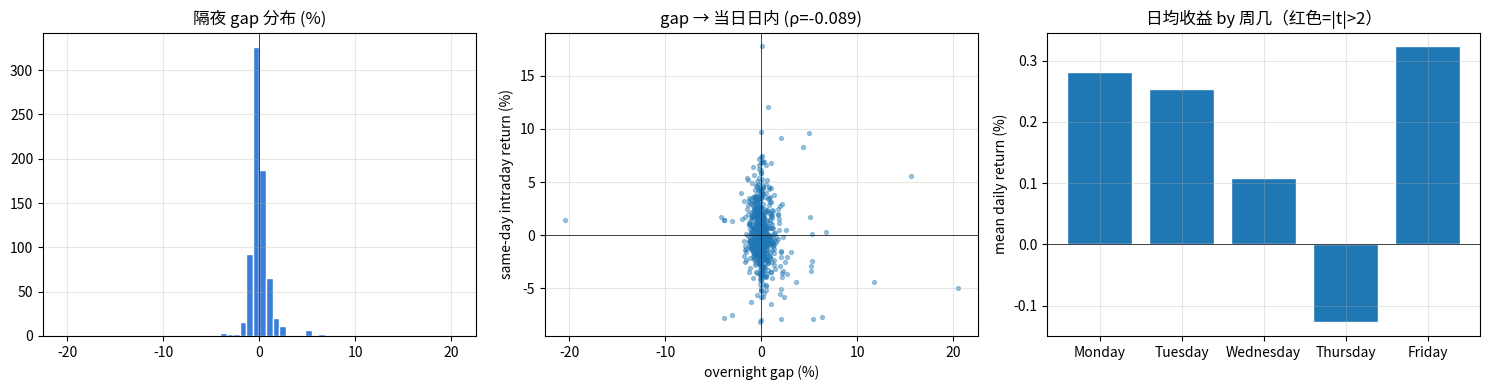

=== overnight gap 五分位 → 当日 intraday 平均 (%) ===
           mean    std  count      t
gap_q                               
Q1(low)   0.454  2.353    149  2.353
Q2        0.396  2.248    148  2.146
Q3       -0.112  2.583    148 -0.528
Q4       -0.081  2.873    148 -0.344
Q5(high) -0.184  3.132    148 -0.714

=== day-of-week 收益 (%) ===
            mean    std  count      t
dow                                  
Monday     0.282  3.413    146  0.998
Tuesday    0.254  2.836    151  1.102
Wednesday  0.108  2.738    149  0.484
Thursday  -0.127  2.513    149 -0.616
Friday     0.323  3.472    146  1.125


In [11]:
df_day["prev_close"]    = df_day["close_price"].shift(1)
df_day["overnight_gap"] = df_day["open_price"] / df_day["prev_close"] - 1
df_day["intraday_ret"]  = df_day["close_price"] / df_day["open_price"] - 1
df_day["next_intraday"] = df_day["intraday_ret"].shift(-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_day["overnight_gap"].dropna() * 100, bins=60, color="#3b7dd8", edgecolor="white")
axes[0].axvline(0, color="black", lw=0.5)
axes[0].set_title("隔夜 gap 分布 (%)"); axes[0].grid(alpha=0.3)

scatter = df_day[["overnight_gap", "intraday_ret"]].dropna()
axes[1].scatter(scatter["overnight_gap"] * 100, scatter["intraday_ret"] * 100,
                s=8, alpha=0.4, color="C0")
rho = scatter.corr().iloc[0, 1]
axes[1].axhline(0, color="black", lw=0.5); axes[1].axvline(0, color="black", lw=0.5)
axes[1].set_xlabel("overnight gap (%)"); axes[1].set_ylabel("same-day intraday return (%)")
axes[1].set_title(f"gap → 当日日内 (ρ={rho:+.3f})"); axes[1].grid(alpha=0.3)

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
dow_stats = df_day.groupby("dow")["ret"].agg(["mean", "std", "count"]).reindex(dow_order)
dow_stats["t"] = dow_stats["mean"] / (dow_stats["std"] / np.sqrt(dow_stats["count"]))
colors = ["C3" if abs(t) > 2 else "C0" for t in dow_stats["t"]]
axes[2].bar(dow_stats.index, dow_stats["mean"] * 100, color=colors, edgecolor="white")
axes[2].axhline(0, color="black", lw=0.5)
axes[2].set_title("日均收益 by 周几（红色=|t|>2）")
axes[2].set_ylabel("mean daily return (%)")
axes[2].grid(alpha=0.3)
fig.tight_layout(); plt.show()

scatter_q = scatter.copy()
scatter_q["gap_q"] = pd.qcut(scatter_q["overnight_gap"], 5,
                              labels=["Q1(low)", "Q2", "Q3", "Q4", "Q5(high)"])
by_q = scatter_q.groupby("gap_q", observed=True)["intraday_ret"].agg(["mean", "std", "count"])
by_q["t"] = by_q["mean"] / (by_q["std"] / np.sqrt(by_q["count"]))
by_q["mean"] *= 100; by_q["std"] *= 100
print("=== overnight gap 五分位 → 当日 intraday 平均 (%) ===")
print(by_q.round(3))

print("\n=== day-of-week 收益 (%) ===")
print(dow_stats.assign(mean=lambda d: d["mean"]*100, std=lambda d: d["std"]*100).round(3))

## 6. 均值回归 vs 动量诊断（多 timeframe 自相关）

ACF 是判断 **「该 timeframe 上动量还是反转」** 的最直接工具：
- ρ(lag=1) < 0 → 反转：上一根涨这一根跌的概率更大
- ρ(lag=1) > 0 → 动量：延续
- 多 timeframe 上同时观察，找到「动量 / 反转分界线」

再用 **variance ratio** 做补充：VR(k) < 1 → 均值回归，VR(k) > 1 → 动量。

=== 多 timeframe 自相关 + Variance Ratio ===
  acf_1 < 0 → 反转；acf_1 > 0 → 动量；VR_k < 1 → 反转；VR_k > 1 → 动量
               n   acf_1   acf_2   acf_5    VR_2    VR_5   VR_10
timeframe                                                       
5min       34592 -0.0214 -0.0088 -0.0030  0.9786  0.9484  0.9359
15min      13247 -0.0180  0.0068 -0.0064  0.9821  0.9674  0.9597
30min       7359 -0.0012 -0.0074  0.0151  0.9989  0.9804  1.0276
60min       4415 -0.0071 -0.0058  0.0182  0.9932  1.0223  1.1085
daily        741  0.0562 -0.0514 -0.0078  1.0568  0.9709  0.8940


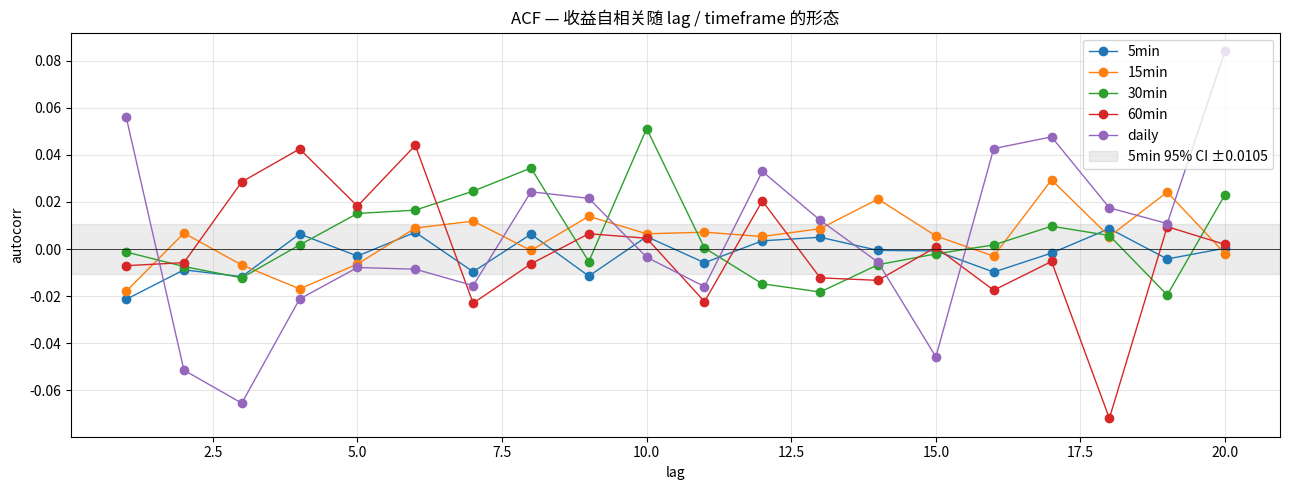

In [12]:
def resample_close(df_5m: pd.DataFrame, rule: str) -> pd.Series:
    return df_5m.set_index("ts_cst")["close_price"].resample(rule).last().dropna()

def variance_ratio(returns: np.ndarray, k: int) -> float:
    """VR(k) = Var(k-period sum) / (k * Var(1-period))."""
    r = returns[~np.isnan(returns)]
    if len(r) < k * 2:
        return np.nan
    var1 = np.var(r, ddof=1)
    rk = pd.Series(r).rolling(k).sum().dropna().values
    vark = np.var(rk, ddof=1)
    return vark / (k * var1)

tfs = {"5min": None, "15min": "15min", "30min": "30min", "60min": "60min", "daily": "day"}
rows = []
acf_curves: dict[str, np.ndarray] = {}
for label, rule in tfs.items():
    if label == "5min":
        r = df_5m["ret_5m"].dropna()
    elif label == "daily":
        r = df_day["ret"].dropna()
    else:
        c = resample_close(df_5m, rule)
        r = c.pct_change().dropna()
    arr = r.values
    rows.append({
        "timeframe": label,
        "n":         len(arr),
        "acf_1":     pd.Series(arr).autocorr(1),
        "acf_2":     pd.Series(arr).autocorr(2),
        "acf_5":     pd.Series(arr).autocorr(5),
        "VR_2":      variance_ratio(arr, 2),
        "VR_5":      variance_ratio(arr, 5),
        "VR_10":     variance_ratio(arr, 10),
    })
    acf_curves[label] = np.array([pd.Series(arr).autocorr(k) for k in range(1, 21)])

acf_df = pd.DataFrame(rows).set_index("timeframe")
print("=== 多 timeframe 自相关 + Variance Ratio ===")
print("  acf_1 < 0 → 反转；acf_1 > 0 → 动量；VR_k < 1 → 反转；VR_k > 1 → 动量")
print(acf_df.round(4))

fig, ax = plt.subplots(figsize=(13, 5))
for label, acf in acf_curves.items():
    ax.plot(range(1, 21), acf, marker="o", lw=1.0, label=label)
ax.axhline(0, color="black", lw=0.5)
n_5m = len(df_5m["ret_5m"].dropna())
ci = 1.96 / np.sqrt(n_5m)
ax.axhspan(-ci, ci, color="gray", alpha=0.15, label=f"5min 95% CI ±{ci:.4f}")
ax.set_xlabel("lag"); ax.set_ylabel("autocorr")
ax.set_title("ACF — 收益自相关随 lag / timeframe 的形态")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 7. 量价结构与跟随性

- **大成交量后续**：top 20% volume 的 5m bar 之后 N bar 平均收益 → 看放量是延续还是反转
- **波动率 regime**：把日波动率分四档，每档下当日 / 次日收益均值是否一致 → 找「高波动日做反转 / 低波动日做动量」之类的条件

In [13]:
df_5m["vol_q"] = df_5m.groupby("date")["volume"].transform(
    lambda s: pd.qcut(s, 5, labels=False, duplicates="drop")
)
horizons = [1, 3, 6, 12]
for h in horizons:
    df_5m[f"fwd_{h}"] = df_5m.groupby("date")["close_price"].transform(
        lambda c: c.shift(-h) / c - 1
    )

rows = []
for h in horizons:
    g = df_5m.dropna(subset=["vol_q", f"fwd_{h}"]).groupby("vol_q")[f"fwd_{h}"]
    means  = g.mean() * 1e4
    counts = g.count()
    stds   = g.std() * 1e4
    for q in means.index:
        rows.append({
            "horizon": f"{h}b",
            "vol_q":   int(q),
            "mean_bp": means[q],
            "std_bp":  stds[q],
            "n":       int(counts[q]),
        })
vol_fwd = pd.DataFrame(rows)
vol_fwd["t"] = vol_fwd["mean_bp"] / (vol_fwd["std_bp"] / np.sqrt(vol_fwd["n"]))
pivot   = vol_fwd.pivot(index="vol_q", columns="horizon", values="mean_bp").round(2)
pivot_t = vol_fwd.pivot(index="vol_q", columns="horizon", values="t").round(2)
print("=== 5m volume 五分位 → 未来 N bar 平均收益 (bp) ===")
print(pivot)
print("\n=== 对应 t-stat（|t|>2 显著）===")
print(pivot_t)

df_day["vol_q"] = pd.qcut(df_day["vol_21d"], 4, labels=["Q1(low)", "Q2", "Q3", "Q4(high)"])
df_day["next_ret"] = df_day["ret"].shift(-1)
by_volq = df_day.dropna(subset=["vol_q"]).groupby("vol_q", observed=True).agg(
    same_day_ret=("ret", "mean"),
    same_day_t  =("ret",      lambda s: s.mean() / s.std() * np.sqrt(len(s))),
    next_day_ret=("next_ret", "mean"),
    next_day_t  =("next_ret", lambda s: s.mean() / s.std() * np.sqrt(len(s))),
    n=("ret", "count"),
)
for c in ("same_day_ret", "next_day_ret"):
    by_volq[c] = (by_volq[c] * 100).round(3)
by_volq[["same_day_t", "next_day_t"]] = by_volq[["same_day_t", "next_day_t"]].round(2)
print("\n=== 滚动波动率四分位 → 当日 / 次日 收益 (%) ===")
print(by_volq)

=== 5m volume 五分位 → 未来 N bar 平均收益 (bp) ===
horizon   12b    1b    3b    6b
vol_q                          
0        7.26  0.86  2.59  4.45
1        2.06  0.33  0.24  0.60
2        0.60  0.16 -0.00 -0.25
3        0.63 -0.39 -0.34  0.47
4        0.65  0.38  1.49  1.49

=== 对应 t-stat（|t|>2 显著）===
horizon   12b    1b    3b    6b
vol_q                          
0        5.39  2.78  4.64  5.46
1        1.59  1.00  0.43  0.72
2        0.45  0.45 -0.00 -0.29
3        0.41 -0.91 -0.46  0.45
4        0.42  0.70  1.63  1.22

=== 滚动波动率四分位 → 当日 / 次日 收益 (%) ===
          same_day_ret  same_day_t  next_day_ret  next_day_t    n
vol_q                                                            
Q1(low)         -0.246       -1.90        -0.183       -1.04  181
Q2               0.138        0.78         0.410        1.65  180
Q3               0.228        1.14         0.298        1.45  180
Q4(high)         0.628        1.86         0.234        0.90  180


## 8. 极端事件：tail z-score / 涨跌停

把 §6 的诊断映射到 z-score 入场：
- 不同 SMA 窗口 (12 / 24 / 48) 下 tail z-score 之后的回归速度
- z > +2 / z < -2 之后未来 N bar 是否真的回归（如果是，幅度多大）
- 涨跌停后第二天的均值漂移

In [14]:
def zscore(close: pd.Series, w: int) -> pd.Series:
    m = close.rolling(w).mean().shift(1)
    s = close.rolling(w).std().shift(1)
    return (close - m) / s

windows  = [12, 24, 48]
horizons = [1, 3, 6, 12, 24]

rows = []
for w in windows:
    z = zscore(df_5m["close_price"], w)
    for h in horizons:
        fwd = df_5m.groupby("date")["close_price"].transform(lambda c: c.shift(-h) / c - 1)
        d = pd.DataFrame({"z": z, "fwd": fwd}).dropna()
        for label, mask in [
            ("z > +2",   d["z"] >  2),
            ("z < -2",   d["z"] < -2),
            ("|z| < 0.5", d["z"].abs() < 0.5),
        ]:
            sub = d.loc[mask, "fwd"]
            if len(sub) < 30:
                continue
            rows.append({
                "window":  w,
                "horizon": h,
                "bucket":  label,
                "n":       len(sub),
                "mean_bp": sub.mean() * 1e4,
                "t":       sub.mean() / (sub.std() / np.sqrt(len(sub))),
            })
tail = pd.DataFrame(rows)
print("=== z-score tail 后 N bar 平均收益 (bp) — 反转 hypothesis 检验 ===")
print("  期望：z>+2 后 fwd 为负 (mean<0, t<0)；z<-2 后 fwd 为正 (mean>0, t>0)")
for w in windows:
    print(f"\n--- SMA window = {w} ---")
    sub = tail[tail["window"] == w].pivot_table(
        index="bucket", columns="horizon",
        values=["mean_bp", "t", "n"], aggfunc="first"
    )
    print(sub.round(2))

lim_thresh = 0.195
df_day["is_limit_up"]   = df_day["ret"] >=  lim_thresh
df_day["is_limit_down"] = df_day["ret"] <= -lim_thresh
n_lu = int(df_day["is_limit_up"].sum())
n_ld = int(df_day["is_limit_down"].sum())
print(f"\n=== 涨跌停事件 ===")
print(f"涨停天: {n_lu}  |  跌停天: {n_ld}  |  总样本: {len(df_day)}")
if n_lu > 5:
    after_lu = df_day.loc[df_day["is_limit_up"], "next_ret"].dropna()
    if len(after_lu) > 5:
        t_lu = after_lu.mean() / (after_lu.std() / np.sqrt(len(after_lu)))
        print(f"涨停后次日: mean={after_lu.mean()*100:+.2f}% | t={t_lu:+.2f} | n={len(after_lu)}")
if n_ld > 5:
    after_ld = df_day.loc[df_day["is_limit_down"], "next_ret"].dropna()
    if len(after_ld) > 5:
        t_ld = after_ld.mean() / (after_ld.std() / np.sqrt(len(after_ld)))
        print(f"跌停后次日: mean={after_ld.mean()*100:+.2f}% | t={t_ld:+.2f} | n={len(after_ld)}")

=== z-score tail 后 N bar 平均收益 (bp) — 反转 hypothesis 检验 ===
  期望：z>+2 后 fwd 为负 (mean<0, t<0)；z<-2 后 fwd 为正 (mean>0, t>0)

--- SMA window = 12 ---
          mean_bp                              n                             t                        
horizon        1     3     6     12     24    1     3     6     12    24    1     3     6     12    24
bucket                                                                                                
z < -2       1.01  2.34  2.75  1.22   6.14  3135  3003  2780  2427  1720  1.49  2.03  1.76  0.54  1.76
z > +2      -0.02  0.40  3.75  6.85  17.25  2985  2891  2733  2441  1628 -0.02  0.29  1.98  2.69  3.87
|z| < 0.5   -0.14  0.19  0.94  1.47   3.89  7931  7579  7087  6016  4039 -0.44  0.35  1.15  1.20  1.78

--- SMA window = 24 ---
          mean_bp                              n                             t                        
horizon        1     3     6     12     24    1     3     6     12    24    1     3     6     12    24
bucket 

## 9. 候选策略假设：分级信号 + 仓位表

把 §3.4 事件去重后的所有 meta-label 自动汇总成一张**可下注信号库**，按 `(|t|, n_events)` 分四档配仓位：

| 档位 | 触发条件 | 建议仓位 | 含义 |
|------|----------|----------|------|
| **high** | \|t\| ≥ 4 且 n ≥ 50 | 90% | 信心高、样本足，可重仓 |
| **medium** | \|t\| ≥ 2.5 且 n ≥ 20 | 70% | 信心中等，常规仓位 |
| **low** | \|t\| ≥ 2 且 n ≥ 10 | 50% | 信号清晰但样本偏小，半仓 |
| **trial** | \|t\| ≥ 2 且 n ≥ 5 | 25% | 试水仓，等价格二次确认再加 |
| reject | 其他 | — | 不入库 |

**direction**：`mean > 0 → long`、`mean < 0 → short / exit`

下面 cell 自动从 `EVENT_LABELS` 构造该表，并写入 `notebooks/cnstock_300866_signals.csv` 供 `scripts/cnstock_<name>_smoke.py` 读取。

### 9.1 验证流程

1. 读取 CSV 后按 `signal_id` 索引，每个候选策略 = 一个或多个 signal_id 的组合
2. 在独立脚本里用 train/test split + walk-forward 复盘，对照 buy-and-hold
3. 关注：**事件互斥规则**（如同一段下跌里"假反弹"已触发空，"深回撤"再触发多前需 confirm "假反弹"已失效）
4. 多股票泛化测试：把同一规则套到其他创业板小票上，看 |t| 是否仍 >2
5. 不通过的候选 → `docs/GinkgoBrain/复盘/` 留 ≤200 字 verdict，关线


In [ ]:
import os

# ── 1. 把 §3.4 的 EVENT_LABELS 合成大表 ──
if not EVENT_LABELS:
    raise RuntimeError("EVENT_LABELS 为空——先跑 §3.4 那个 cell")

board = pd.concat(EVENT_LABELS, ignore_index=True)
board["abs_t"]     = board["t"].abs()
board["indicator"] = board["indicator"].str.replace(" (event)", "", regex=False)

# ── 2. 只保留 |t| ≥ 2 的可下注信号 ──
sig = board[board["abs_t"] >= 2.0].copy()


# ── 3. tier + size 分级规则 ──
def _assign_tier(row) -> tuple[str, int]:
    t, n = row["abs_t"], row["n"]
    if t >= 4.0 and n >= 50:  return ("high",   90)
    if t >= 2.5 and n >= 20:  return ("medium", 70)
    if t >= 2.0 and n >= 10:  return ("low",    50)
    if t >= 2.0 and n >= 5:   return ("trial",  25)
    return ("reject", 0)


sig[["tier", "size_pct"]] = sig.apply(lambda r: pd.Series(_assign_tier(r)), axis=1)
sig = sig[sig["tier"] != "reject"].copy()

# ── 4. direction：long if mean>0 else short ──
sig["direction"] = np.where(sig["mean_pct"] > 0, "long", "short")

# ── 5. signal_id（脚本里的 stable key）──
sig["signal_id"] = (
    sig["indicator"]
    + "::" + sig["regime"].str.replace(r"[^\w\u4e00-\u9fff]", "_", regex=True)
    + "::h" + sig["h"].astype(str)
)

# ── 6. 排序：按 tier 优先级、|t| 降序 ──
tier_order = {"high": 0, "medium": 1, "low": 2, "trial": 3}
sig["_ord"] = sig["tier"].map(tier_order)
sig = sig.sort_values(["_ord", "abs_t"], ascending=[True, False]).drop(columns=["_ord", "abs_t"])

# ── 7. 输出 ──
out_cols = ["signal_id", "indicator", "regime", "h", "direction", "n",
            "mean_pct", "win_pct", "sharpe_ann", "t", "tier", "size_pct"]
print("=== 300866 可下注 meta-label 信号库（事件去重，|t|>=2）===")
print(sig[out_cols].to_string(index=False))

# 各 tier 计数
print("\n=== tier 计数 ===")
print(sig["tier"].value_counts().reindex(["high", "medium", "low", "trial"]).fillna(0).astype(int))

# 写盘 — 下游 scripts/cnstock_<name>_smoke.py 读取
out_path = REPO_ROOT / "notebooks" / "cnstock_300866_signals.csv"
sig[out_cols].to_csv(out_path, index=False, encoding="utf-8")
print(f"\n→ 已写入 {out_path}")
print(f"  共 {len(sig)} 条信号；下游脚本可用 pd.read_csv(path) 加载")
